# 📝 Exercise M6.02

The aim of this exercise it to explore some attributes available in
scikit-learn's random forest.

First, we will fit the penguins regression dataset.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

penguins = pd.read_csv("../datasets/penguins_regression.csv")
feature_name = "Flipper Length (mm)"
target_name = "Body Mass (g)"
data, target = penguins[[feature_name]], penguins[target_name]
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=0
)

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Note</p>
<p class="last">If you want a deeper overview regarding this dataset, you can refer to the
Appendix - Datasets description section at the end of this MOOC.</p>
</div>

Create a random forest containing three trees. Train the forest and check the
generalization performance on the testing set in terms of mean absolute error.

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error


rf = RandomForestRegressor(n_estimators=3, random_state=0)

rf.fit(data_train, target_train)

y_true = target_test
y_pred_rf = rf.predict(data_test)

print(mean_absolute_error(y_true, y_pred_rf),"g")

345.3494091107379 g


We now aim to plot the predictions from the individual trees in the forest.
For that purpose you have to create first a new dataset containing evenly
spaced values for the flipper length over the interval between 170 mm and 230
mm.

In [3]:
import numpy as np

data_new = np.linspace(170, 230)
data_new = pd.DataFrame(data_new)

The trees contained in the forest that you created can be accessed with the
attribute `estimators_`. Use them to predict the body mass corresponding to
the values in this newly created dataset. Similarly find the predictions of
the random forest in this dataset.

In [5]:
rf1 = rf.estimators_[0]
rf2 = rf.estimators_[1]
rf3 = rf.estimators_[2]

y_rf1 = rf1.predict(data_new)
y_rf2 = rf2.predict(data_new)
y_rf3 = rf3.predict(data_new)

y_rf = rf.predict(data_new)

C:\Users\Aymen\miniconda3\envs\scikit-learn-course\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Now make a plot that displays:
- the whole `data` using a scatter plot;
- the decision of each individual tree;
- the decision of the random forest.

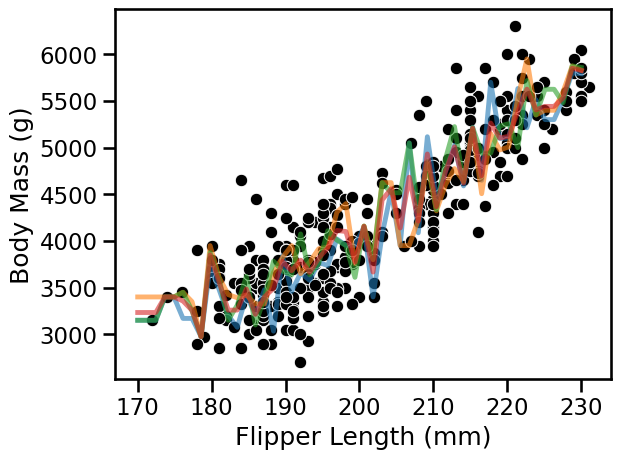

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

_ = sns.scatterplot(data=penguins, x=feature_name, y=target_name, color="black")
_ = plt.plot(data_new[0], y_rf1, alpha=0.6)
_ = plt.plot(data_new[0], y_rf2, alpha=0.6)
_ = plt.plot(data_new[0], y_rf3, alpha=0.6)
_ = plt.plot(data_new[0], y_rf, alpha=0.6)